<a href="https://colab.research.google.com/github/MontanezQuirozRolo/-MachineLearning_West-Airlines/blob/main/SegClientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentacion de Clientes para una Plataformna E-Comerce

Una empresa de e-comerce desea mejorar sus estrategias de marketing y retencion de clientes. Para ello necesita segmentar su base de usuarios con el fin de identificar distintos tipo de comportamiento de compra y diseñar campañas personalizadas. Nuestro objetivo es aplicar tecnicas de segmentacion (K-means  o DBSCAN) para identificar grupos de clientes con comportamientos similares en sus patrones de uso y gasto

## Variables a evaluar
* customer_id (Numérica ID): Es la llave primaria. No aporta valor predictivo ni de comportamiento.
* avg_monthly_spend (Numérica continua): Es el indicador directo del valor del cliente para el negocio. Ayuda a separar a los "cazadores de ofertas" de los clientes "VIP" o de alto valor (High-Ticket).
* num_transactions (Numérica entera): Mide la frecuencia de compra real.
* visit_frequency (Numérica entera): promedio de visitas al mes
* avg_session_duration (Numérica continua): Mide la profundidad de la interacción. Sesiones cortas con alta conversión hablan de un comprador decidido. Sesiones muy largas con nula conversión podrían señalar fricción en el embudo de ventas, problemas de usabilidad web, o un proceso de investigación profundo para compras complejas.
* customer_tenure (Numérica continua): La antigüedad en meses permite distinguir entre los "early adopters" leales y los recién adquiridos.
* preferred_channel (Categórica): Define dónde vas a impactar al cliente. No tiene sentido gastar presupuesto en un correo si el cliente interactúa exclusivamente por notificaciones push en la "App".
* country_region (Categórica): Region de procedencia



In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

## Carga y limpieza de datos

In [2]:
df = pd.read_excel('ecommerce_customers.xlsx')

In [3]:
display(df.head())

,customer_id,avg_monthly_spend,visit_frequency,avg_session_duration,num_transactions,customer_tenure,preferred_channel,country_region
0,1,359.61,11,7.32,3,58,Web,North America
1,2,283.41,11,9.10,6,35,Web,Latam
2,3,377.72,5,10.74,5,18,App,Europe
3,4,482.76,7,5.59,6,11,App,Latam
4,5,271.90,7,12.48,1,54,Web,Latam


In [4]:
df.shape

(500, 8)

In [5]:
df.dtypes

,0
customer_id,int64
avg_monthly_spend,float64
visit_frequency,int64
avg_session_duration,float64
num_transactions,int64
customer_tenure,int64
preferred_channel,object
country_region,object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           500 non-null    int64  
 1   avg_monthly_spend     500 non-null    float64
 2   visit_frequency       500 non-null    int64  
 3   avg_session_duration  500 non-null    float64
 4   num_transactions      500 non-null    int64  
 5   customer_tenure       500 non-null    int64  
 6   preferred_channel     500 non-null    object 
 7   country_region        500 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 31.4+ KB


In [7]:
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
customer_id             0
avg_monthly_spend       0
visit_frequency         0
avg_session_duration    0
num_transactions        0
customer_tenure         0
preferred_channel       0
country_region          0
dtype: int64


Se va elimninar la columna de id por que no es relevante para el analisis

In [8]:
df = df.drop('customer_id', axis=1)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   avg_monthly_spend     500 non-null    float64
 1   visit_frequency       500 non-null    int64  
 2   avg_session_duration  500 non-null    float64
 3   num_transactions      500 non-null    int64  
 4   customer_tenure       500 non-null    int64  
 5   preferred_channel     500 non-null    object 
 6   country_region        500 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 27.5+ KB


## Análisis Exploratorio de Datos (EDA)

In [10]:
sns.set_theme(style="whitegrid")
numeric_cols = ['avg_monthly_spend', 'visit_frequency', 'avg_session_duration', 'num_transactions', 'customer_tenure']
categorical_cols = ['preferred_channel', 'country_region']

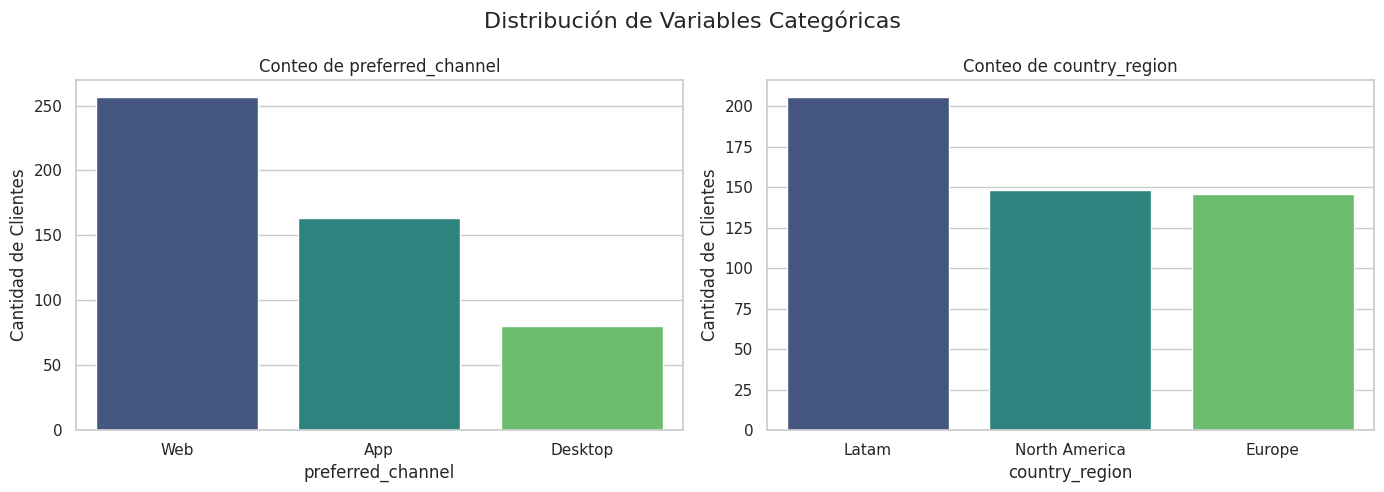

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Variables Categóricas', fontsize=16)

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, palette='viridis', ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Conteo de {col}')
    axes[i].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

* Preferred Channel (Canal preferido)
  * Existe una clara preferencia por el canal Web, lo que sugiere que la mayoría de clientes interactúa desde navegadores o plataformas web.
* Country Region (Región geográfica)
  * La mayor concentración de clientes está en Latinoamérica, por lo que parece ser el mercado principal.


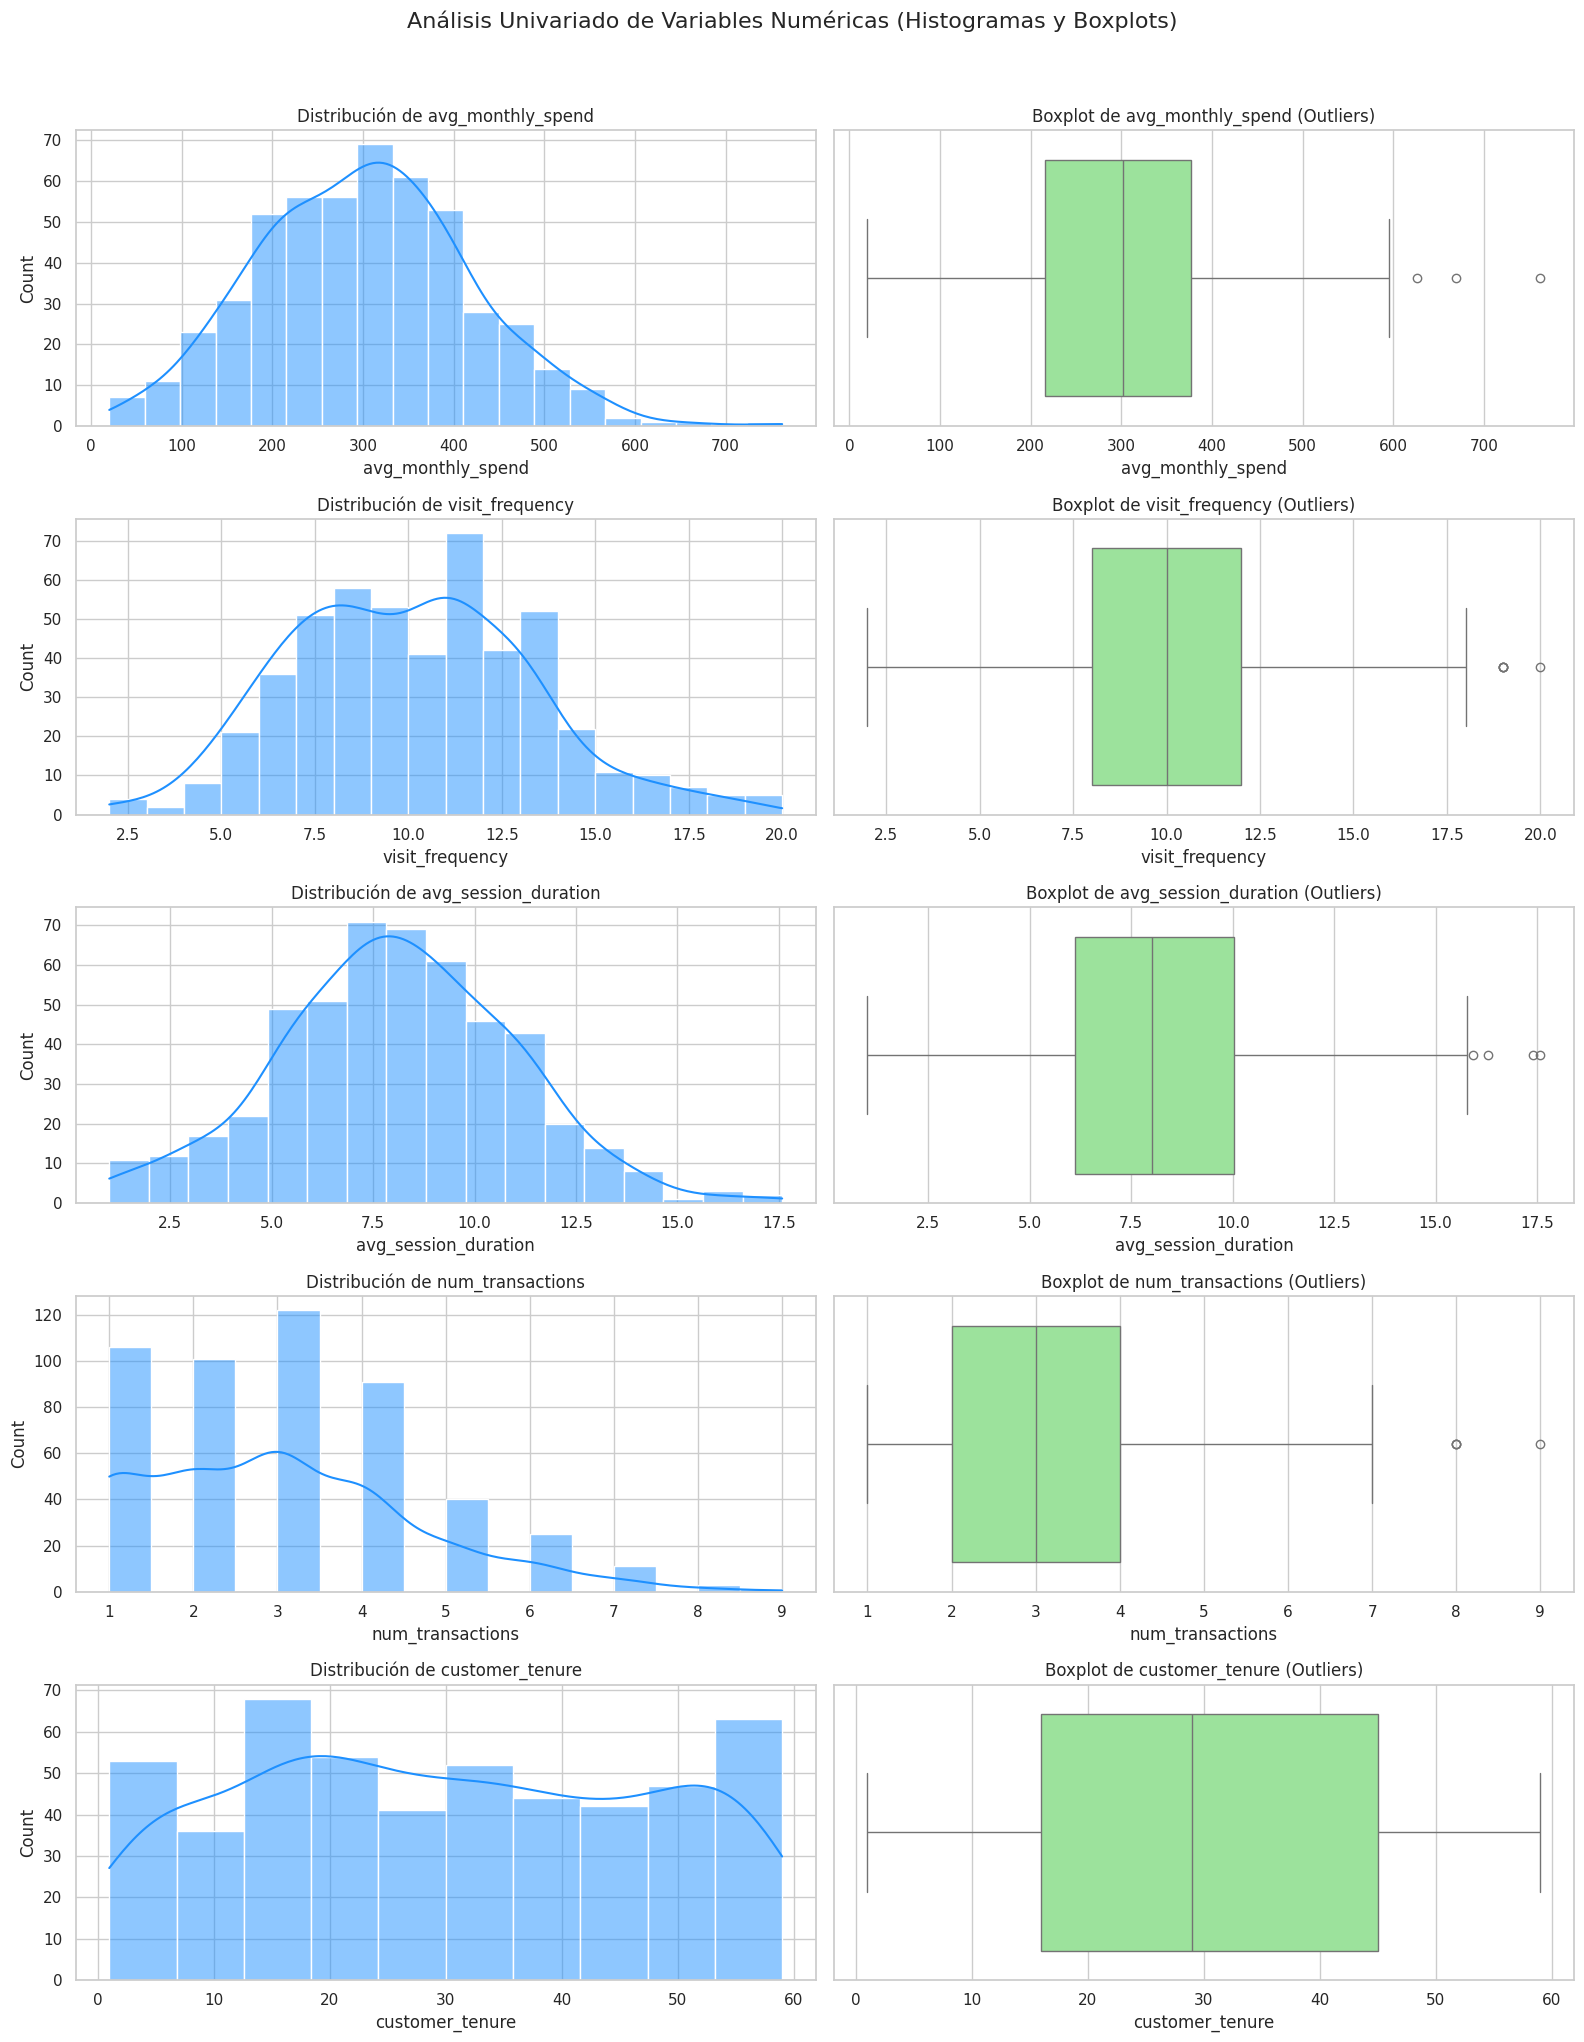

In [12]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(16, 4 * len(numeric_cols)))
fig.suptitle('Análisis Univariado de Variables Numéricas (Histogramas y Boxplots)', fontsize=16, y=1.02)

for i, col in enumerate(numeric_cols):
    # Histograma (Distribución)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='dodgerblue')
    axes[i, 0].set_title(f'Distribución de {col}')

    # Boxplot (Detección de Outliers)
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot de {col} (Outliers)')

plt.tight_layout()
plt.show()

* avg_monthly_spend
  * La distribución tiene una ligera asimetría positiva (cola hacia la derecha).
  * la mayoría de clientes tiene un comportamiento de gasto moderado, pero existe un pequeño grupo que gasta considerablemente más
  * outliers representan clientes con gasto extraordinariamente alto
* visit_frequency
  * La mayoría de clientes tiene una frecuencia de interacción relativamente estable y moderada.
  * Estos casos representan clientes extremadamente activos o recurrentes.
* avg_session_duration
   * la mayoría de usuarios mantiene sesiones de duración moderada
   * Estos outliers representan usuarios con sesiones excepcionalmente largas
* num_transactions
  * existe una gran concentración de clientes con baja actividad transaccional, mientras que pocos clientes realizan muchas transacciones.
  * Presencia de outliers altos en valores cercanos a 8 y 9 transacciones
* customer_tenure
  * La distribución es relativamente uniforme, aunque con ligeras concentraciones en ciertos rangos.
  * Ausencia de outliers

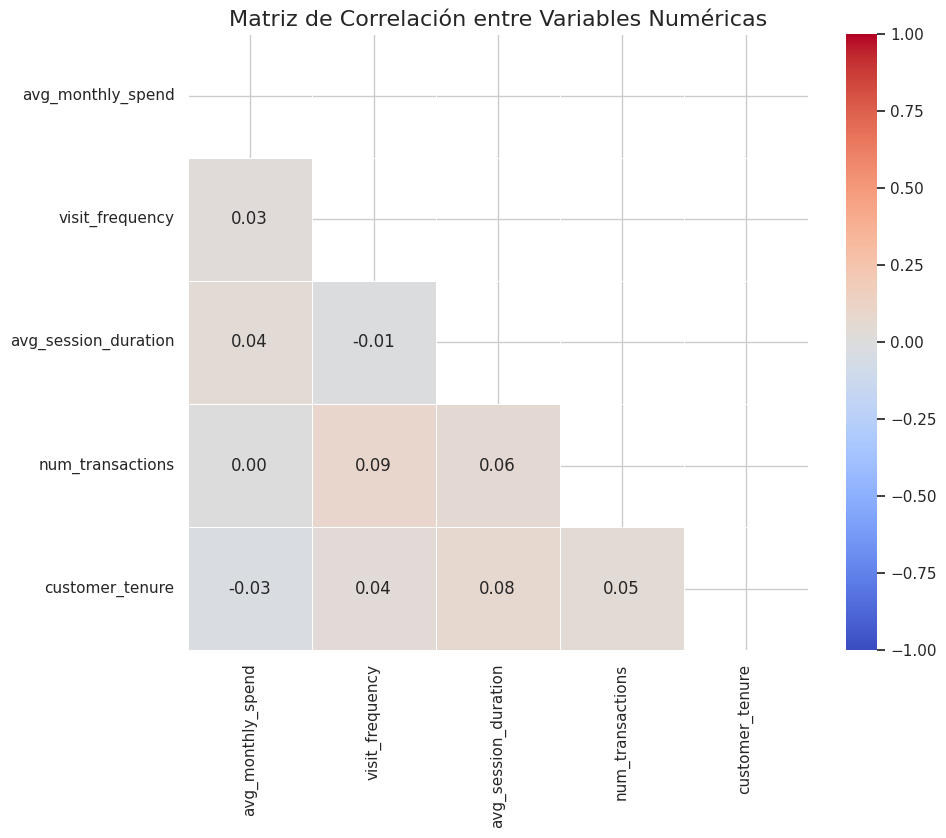

In [13]:
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=16)
plt.show()

* La matriz evidencia que todas las correlaciones son muy bajas, ya que los valores oscilan aproximadamente entre -0.03 y 0.09.
* no existen relaciones lineales fuertes entre las variables numéricas,

## Preprocesamiento (Escalado y Codificación)

Dividimos los datos entre numericos y categoricos para poder realizar el escalado

In [24]:
numeric_features = [
    'avg_monthly_spend',
    'visit_frequency',
    'avg_session_duration',
    'num_transactions',
    'customer_tenure'
]

categorical_features = [
    'preferred_channel',
    'country_region'
]

Generamos el pipeline para los valores numericos y categoricos

In [21]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [22]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])


In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [26]:
X_processed = preprocessor.fit_transform(df)

In [27]:
encoded_columns = preprocessor.named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(categorical_features)

In [28]:
final_columns = numeric_features + list(encoded_columns)
X_processed_df = pd.DataFrame(
    X_processed,
    columns=final_columns
)


In [29]:
print("Dimensiones del dataset transformado:")
print(X_processed_df.shape)

print("\nPrimeras filas:")
print(X_processed_df.head())

Dimensiones del dataset transformado:
(500, 9)

Primeras filas:
   avg_monthly_spend  visit_frequency  avg_session_duration  num_transactions  \
0           0.500732         0.317305             -0.259284          0.002492   
1          -0.151473         0.317305              0.353681          1.871666   
2           0.655738        -1.531073              0.918435          1.248608   
3           1.554789        -0.914947             -0.855031          1.871666   
4          -0.249989        -0.914947              1.517625         -1.243624   

   customer_tenure  preferred_channel_Desktop  preferred_channel_Web  \
0         1.620491                        0.0                    1.0   
1         0.287660                        0.0                    1.0   
2        -0.697476                        0.0                    0.0   
3        -1.103121                        0.0                    0.0   
4         1.388694                        0.0                    1.0   

   country_regio

Ahora que se han escalado los valores estan alrededor de media 0 y desviacion estandar 1
* Las variables numericas estan normalizadas
* Las variables categoricas fueron convertidas a formato numerico manteniendo la informacion original

## Segmentación

### K-Means

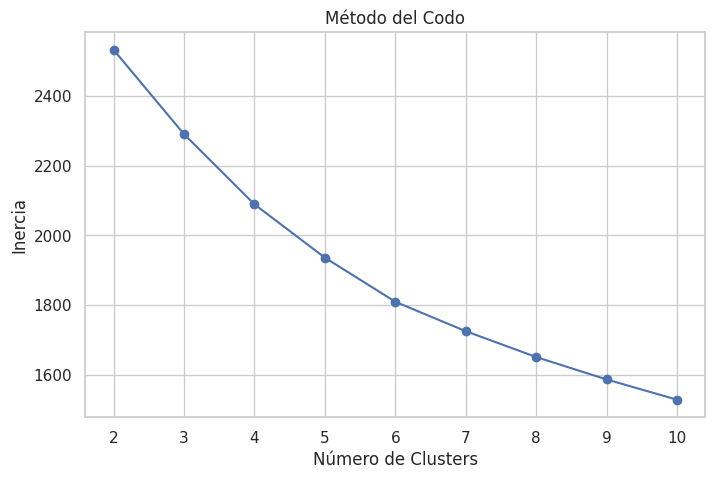

In [30]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_processed_df)

    inertia.append(kmeans.inertia_)

# Gráfico del codo
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.show()


* La gráfica muestra cómo disminuye la inercia conforme aumenta el número de clusters.
* Entre 2 y 5 clusters la caída es bastante pronunciada,
* Se sugiere usar K = 5 o K = 6

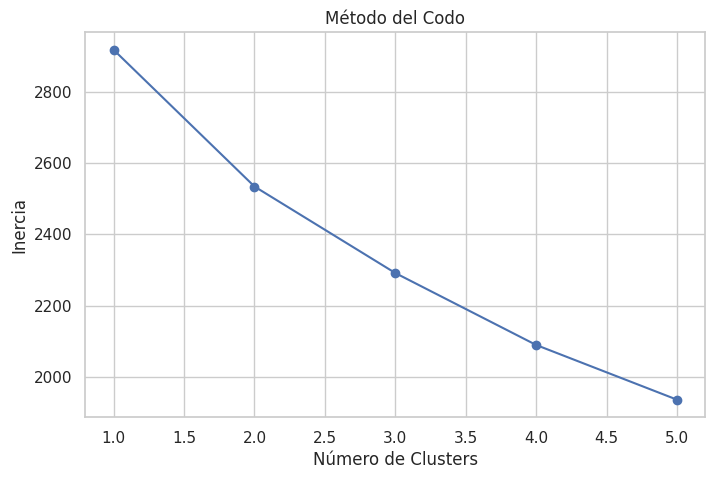

In [42]:
inertia = []

K = [1,2,3,4,5]

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_processed_df)

    inertia.append(kmeans.inertia_)

# Gráfico del codo
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.show()


In [45]:
kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters_kmeans = kmeans_final.fit_predict(X_processed_df)

# Agregar clusters al dataframe original
df['cluster_kmeans'] = clusters_kmeans

In [46]:
silhouette = silhouette_score(X_processed_df, clusters_kmeans)
print("Silhouette Score:", silhouette)
print(df['cluster_kmeans'].value_counts())

Silhouette Score: 0.11920150895676634
cluster_kmeans
0    113
1    107
3    104
4     95
2     81
Name: count, dtype: int64


* los clusters tienen baja separación.
* muchos clientes son similares entre sí, los grupos se superponen,

### Cluster Jerarquico

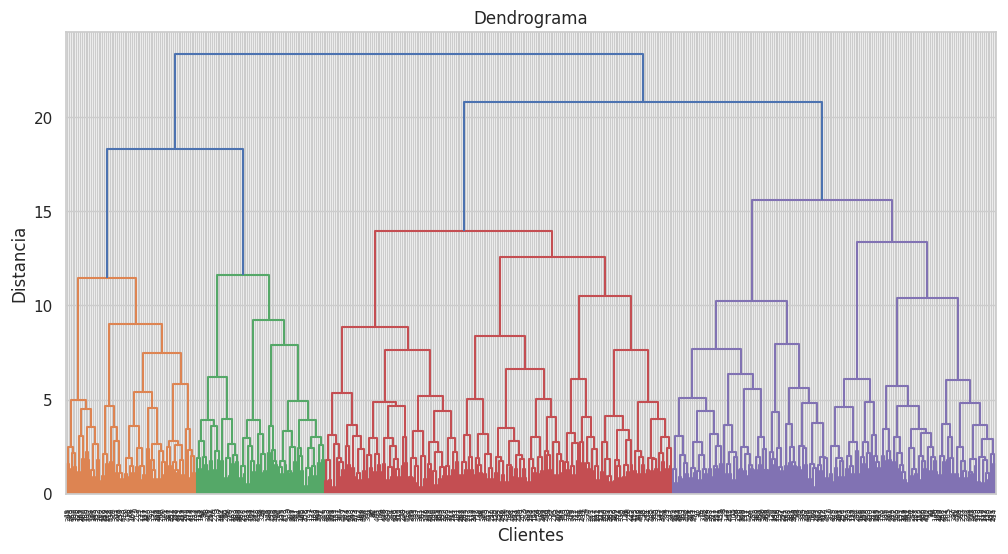

In [50]:
linked = linkage(X_processed_df, method='ward')

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title('Dendrograma')
plt.xlabel('Clientes')
plt.ylabel('Distancia')

plt.show()

* Se observan aproximadamente: 4 grandes grupos principales (naranja, verde, rojo y morado).
* Se distinguen ramas relativamente definidas.
* No parece existir un único cluster dominante.
* Hay cierta organización natural de clientes.

In [57]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

clusters_hier = hierarchical.fit_predict(X_processed_df)

df['cluster_hierarchical'] = clusters_hier

In [58]:
silhouette_hier = silhouette_score(
    X_processed_df,
    clusters_hier
)

print("Silhouette Score:", silhouette_hier)
print(df['cluster_hierarchical'].value_counts())

Silhouette Score: 0.08290907100261583
cluster_hierarchical
2    187
0    174
3     70
1     69
Name: count, dtype: int64


* El clustering jerárquico: separó peor los grupos que K-Means, y generó clusters más solapados.
* Dos grupos grandes,y dos grupos pequeños.

### DBSCAN


In [86]:

dbscan = DBSCAN(
    eps=1.2,
    min_samples=5
)

clusters_dbscan = dbscan.fit_predict(X_processed_df)

df['cluster_dbscan'] = clusters_dbscan

print(df['cluster_dbscan'].value_counts())

cluster_dbscan
-1     348
 2      67
 1      32
 8      11
 0       9
 10      6
 7       6
 9       5
 4       5
 5       5
 6       4
 3       2
Name: count, dtype: int64


* DBSCAN fragmentó los datos, creando microgrupos pequeños y dejando la mayoría como ruido.


In [87]:
mask = clusters_dbscan != -1

if len(set(clusters_dbscan[mask])) > 1:

    score_dbscan = silhouette_score(
        X_processed_df[mask],
        clusters_dbscan[mask]
    )

    print("Silhouette Score:", score_dbscan)

else:
    print("DBSCAN encontró pocos clusters válidos.")

Silhouette Score: 0.031261302393284854


* Es un score extremadamente bajo.
* los clusters: están muy solapados, poco separados, y con baja cohesión interna.

### PCA

In [89]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed_df)

In [90]:
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("\nVarianza acumulada:")
print(pca.explained_variance_ratio_.cumsum())

Varianza explicada por cada componente:
[0.19819266 0.17754421]

Varianza acumulada:
[0.19819266 0.37573688]


Las dos componentes principales capturan aproximadamente: el 37.6% de la información total del dataset lo que es aceptable.

In [91]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

#### KMEANS SOBRE PCA

In [92]:
kmeans_pca = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters_pca = kmeans_pca.fit_predict(pca_df)

# Agregar clusters
pca_df['cluster'] = clusters_pca

In [93]:
silhouette_pca = silhouette_score(
    pca_df[['PC1', 'PC2']],
    clusters_pca
)

print("\nSilhouette Score PCA + KMeans:")
print(silhouette_pca)


Silhouette Score PCA + KMeans:
0.32844795483413475


* los clusters tienen mejor cohesión y mayor separación entre segmentos.
* moderadamente aceptable para segmentación de clientes pero indica grupos más distinguibles, patrones más útiles para negocio.

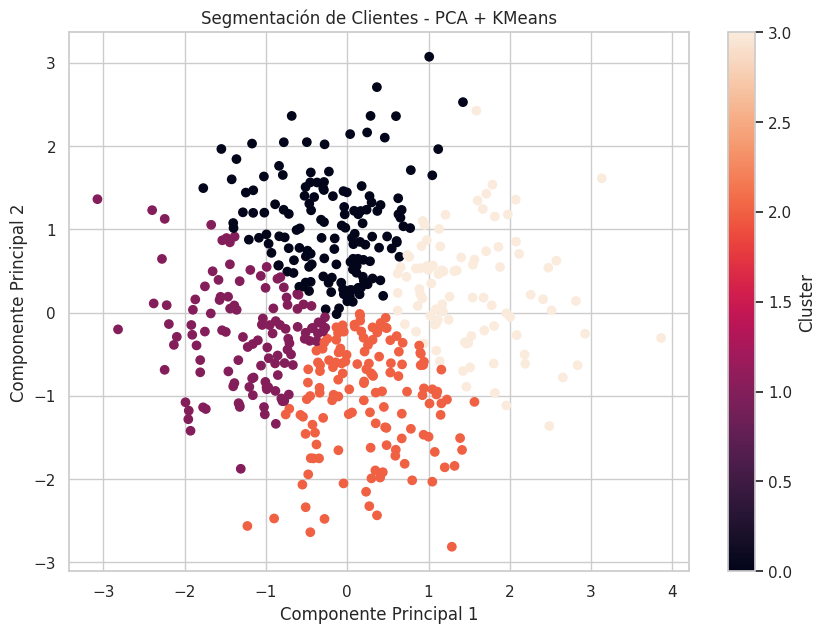

In [94]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster']
)

plt.title('Segmentación de Clientes - PCA + KMeans')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.colorbar(scatter, label='Cluster')

plt.show()

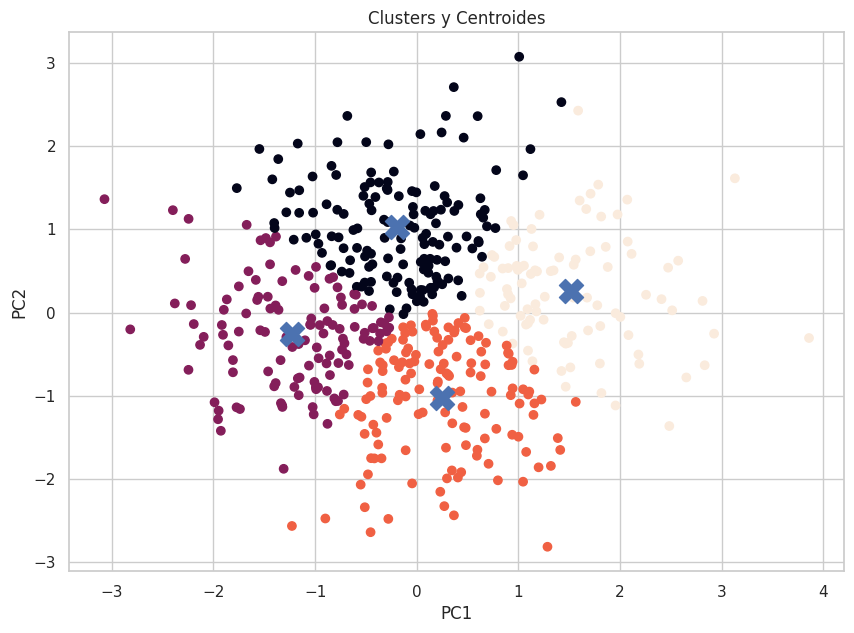

In [95]:

centroids = kmeans_pca.cluster_centers_

plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster']
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    marker='X'
)

plt.title('Clusters y Centroides')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

* 4 grupos relativamente diferenciados.
* Aunque todavía existe cierto solapamiento: la separación es mucho mejor que antes.


In [96]:
df['cluster_pca_kmeans'] = clusters_pca

In [97]:
cluster_profile = df.groupby(
    'cluster_pca_kmeans'
)[[
    'avg_monthly_spend',
    'visit_frequency',
    'avg_session_duration',
    'num_transactions',
    'customer_tenure'
]].mean()

print("\nPerfil promedio de clusters:")
print(cluster_profile)


Perfil promedio de clusters:
                    avg_monthly_spend  visit_frequency  avg_session_duration  \
cluster_pca_kmeans                                                             
0                          361.536054        11.755102              6.713469   
1                          261.437083         7.733333              6.825333   
2                          251.416170         8.475177              9.515887   
3                          332.453478        12.326087              9.660978   

                    num_transactions  customer_tenure  
cluster_pca_kmeans                                     
0                           2.979592        20.346939  
1                           1.850000        20.725000  
2                           2.836879        41.851064  
3                           4.760870        39.554348  


Cluster 0: Clientes activos de corto plazo.
* Gasto	Alto
* Frecuencia	Alta
* Sesión	Baja
* Transacciones	Medias
* Antigüedad	Baja

Cluster 1: Clientes de bajo engagement.
* Gasto	Bajo
* Frecuencia	Baja
* Sesión	Baja
* Transacciones	Muy bajas
* Antigüedad	Baja

Cluster 2: Clientes leales y comprometidos.
* Gasto	Bajo
* Frecuencia	Media
* Sesión	Alta
* Transacciones	Medias
* Antigüedad	Muy alta

Cluster 3: Clientes premium / alto valor.
* Gasto	Alto
* Frecuencia	Muy alta
* Sesión	Alta
* Transacciones	Muy altas
* Antigüedad	Alta



## Conclusión Final

El análisis de segmentación de clientes permitió identificar patrones de comportamiento relevantes a partir de variables relacionadas con gasto promedio, frecuencia de visitas, duración de sesión, número de transacciones, antigüedad, canal preferido y región geográfica.

Durante la etapa exploratoria se observó que las variables presentaban correlaciones bajas y comportamientos relativamente homogéneos, lo que dificultó inicialmente la formación de clusters claramente diferenciados. Se aplicaron técnicas de preprocesamiento como estandarización de variables numéricas y codificación One-Hot Encoding para variables categóricas, preparando adecuadamente los datos para algoritmos de clustering.

Se evaluaron distintos enfoques de segmentación, incluyendo K-Means, Clustering Jerárquico y DBSCAN. Entre ellos, K-Means mostró el mejor desempeño inicial, aunque con una separación moderada entre grupos. Posteriormente, la aplicación de PCA permitió reducir el ruido y concentrar la información más relevante del dataset, mejorando significativamente la calidad de segmentación.

El modelo final PCA + K-Means alcanzó un Silhouette Score de aproximadamente 0.33, evidenciando una separación aceptable entre segmentos y permitiendo identificar cuatro perfiles principales de clientes:

* Clientes activos recientes
* Clientes de bajo engagement
* Clientes leales tradicionales
* Clientes premium de alto valor

Estos segmentos proporcionan información valiosa para la toma de decisiones estratégicas, permitiendo diseñar acciones diferenciadas de fidelización, retención, personalización y optimización comercial según el perfil de cada grupo de clientes.

Finalmente, el proyecto demuestra cómo técnicas de análisis exploratorio, reducción de dimensionalidad y machine learning no supervisado pueden integrarse para generar conocimiento accionable y apoyar estrategias centradas en el cliente.